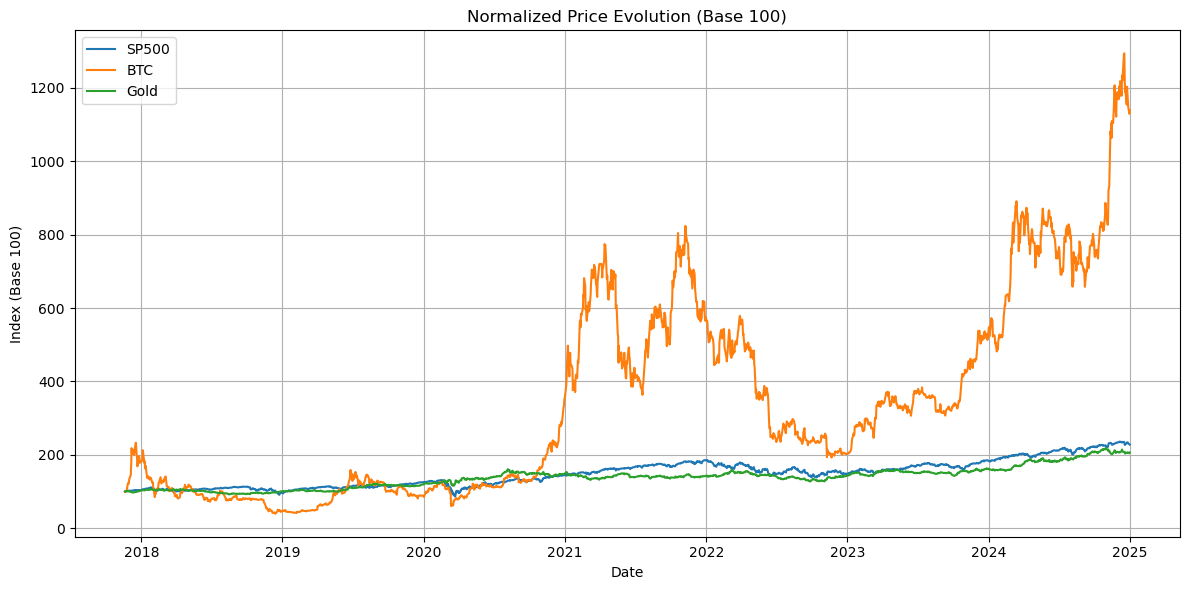

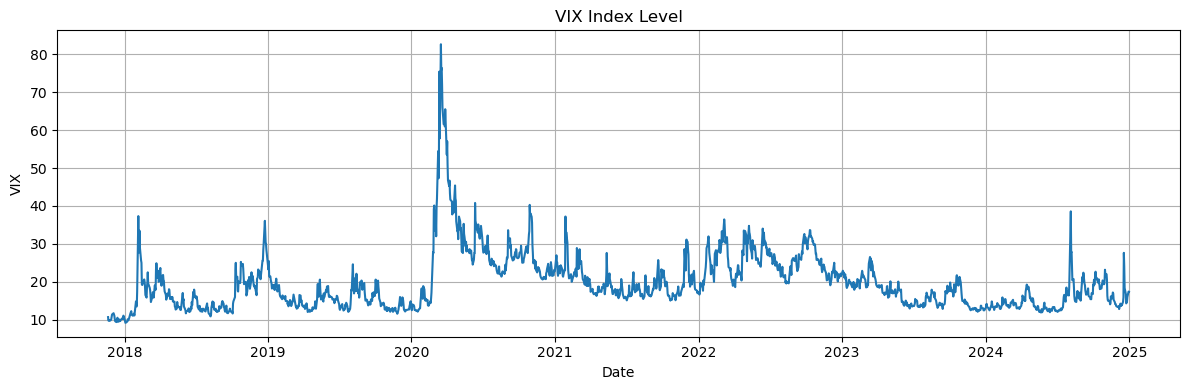

In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
from arch import arch_model
from xgboost import XGBRegressor

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error,
    accuracy_score, confusion_matrix,
    roc_auc_score, roc_curve
)


# GENERAL PARAMETERS

START_DATE = "2017-11-20"
END_DATE   = "2025-01-01"

WINDOW_VOL  = 30   # window for realized volatility (rolling std)
WINDOW_CORR = 30   # window for rolling correlation
HORIZON     = 5    # forecasting horizon (e.g. predict 5 days ahead)

# Download raw price data

tickers = {
    "SP500": "^GSPC",
    "BTC":   "BTC-USD",
    "Gold":  "GC=F",
    "VIX":   "^VIX",
}

raw = yf.download(
    list(tickers.values()),
    start=START_DATE,
    end=END_DATE,
    auto_adjust=True,
    progress=False
)["Close"]

# Robust renaming: map each Yahoo ticker to our clean name
name_map = {v: k for k, v in tickers.items()}
raw = raw.rename(columns=name_map)


# Align data and drop incomplete days (prices only)

prices = raw.asfreq("B")  # business days
cols_assets = ["SP500", "BTC", "Gold", "VIX"]
prices = prices.dropna(subset=cols_assets)  # only days where all 4 exist


# A3 — returns, volatility, correlation

df = prices.copy()

# Log prices
log_prices = np.log(df[cols_assets])

# Log returns
for col in cols_assets:
    df[f"ret_{col}"] = log_prices[col].diff()

# Volatility (rolling std on returns)
for col in cols_assets:
    df[f"vol_{col}"] = df[f"ret_{col}"].rolling(WINDOW_VOL).std()

# Rolling correlation BTC–SP500
df["corr_BTC_SP500"] = (
    df["ret_BTC"].rolling(WINDOW_CORR).corr(df["ret_SP500"])
)

# Annualized volatility (optional)
for col in cols_assets:
    df[f"vol_ann_{col}"] = df[f"vol_{col}"] * np.sqrt(252)

# Drop rows where returns are NaN (début des séries)
df_base = df.dropna(subset=["ret_SP500", "ret_BTC", "ret_Gold", "ret_VIX"])

# Basic visualizations

# Normalized prices (base 100)
assets = ["SP500", "BTC", "Gold"]

norm_prices = prices[assets].divide(prices[assets].iloc[0]) * 100

plt.figure(figsize=(12, 6))
for col in assets:
    plt.plot(norm_prices.index, norm_prices[col], label=col)

plt.title("Normalized Price Evolution (Base 100)")
plt.xlabel("Date")
plt.ylabel("Index (Base 100)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


# VIX level
plt.figure(figsize=(12, 4))
plt.plot(prices.index, prices["VIX"])
plt.title("VIX Index Level")
plt.xlabel("Date")
plt.ylabel("VIX")
plt.grid(True)
plt.tight_layout()
plt.show()

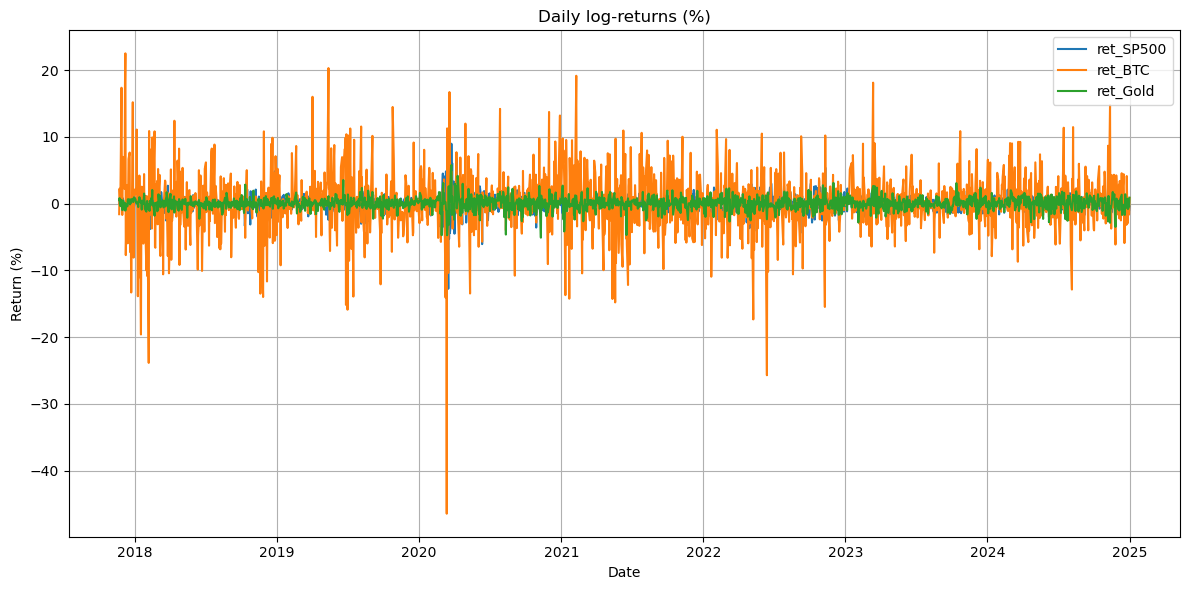

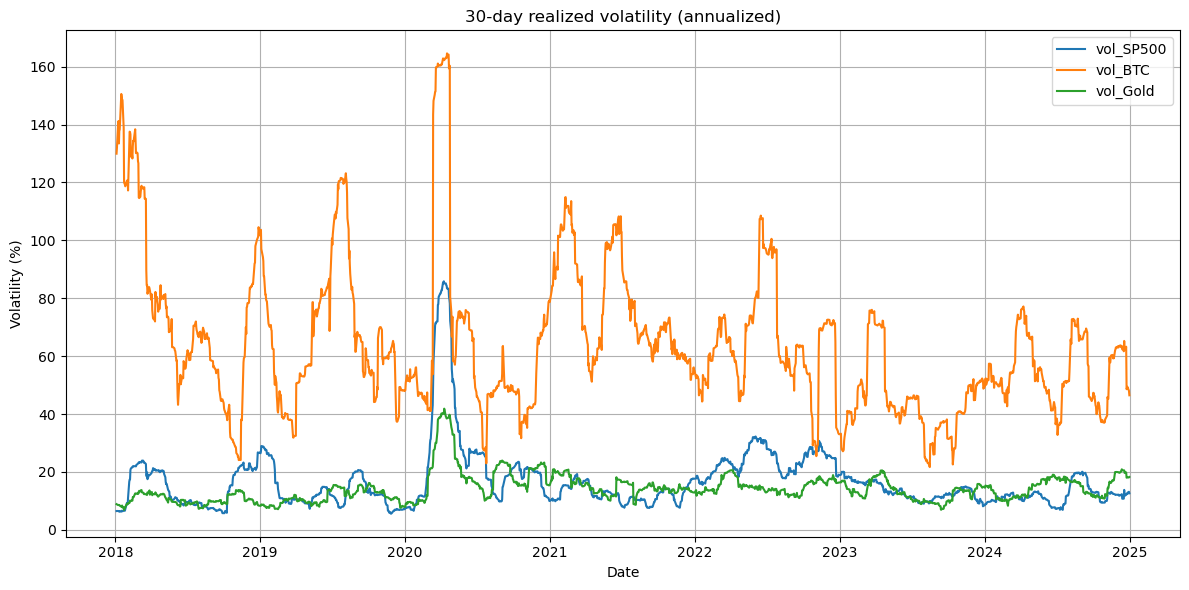

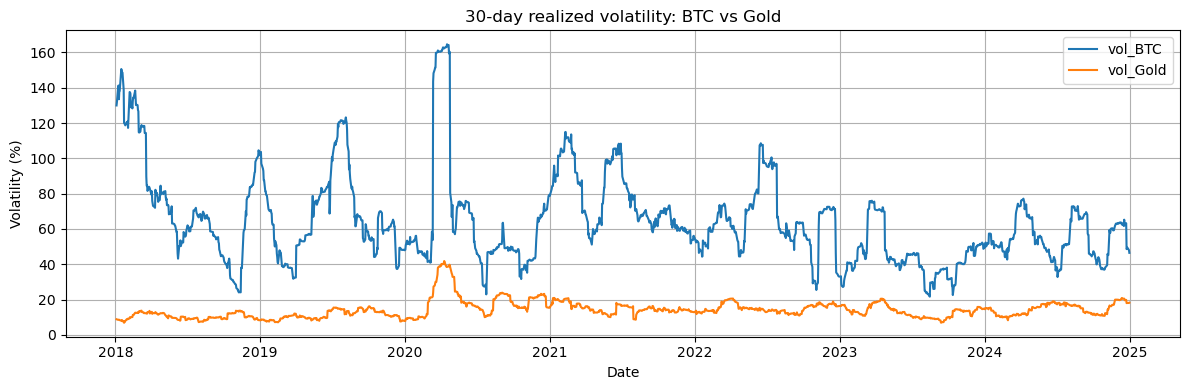

In [2]:
# Returns plots

# Columns for returns (matching your naming)
assets_ret = ["ret_SP500", "ret_BTC", "ret_Gold"]

# Convert log-returns to percentage for plotting
returns_pct = df_base[assets_ret] * 100

plt.figure(figsize=(12, 6))
for col in assets_ret:
    plt.plot(returns_pct.index, returns_pct[col], label=col)

plt.title("Daily log-returns (%)")
plt.xlabel("Date")
plt.ylabel("Return (%)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


# Volatility plots (annualized)


vol_cols = ["vol_SP500", "vol_BTC", "vol_Gold"]

# Precompute annualized vol in %
ann_vol = df_base[vol_cols] * np.sqrt(252) * 100

plt.figure(figsize=(12, 6))
for col in vol_cols:
    plt.plot(ann_vol.index, ann_vol[col], label=col)

plt.title(f"{WINDOW_VOL}-day realized volatility (annualized)")
plt.xlabel("Date")
plt.ylabel("Volatility (%)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


# BTC vs Gold volatility comparison
plt.figure(figsize=(12, 4))
plt.plot(ann_vol.index, ann_vol["vol_BTC"],  label="vol_BTC")
plt.plot(ann_vol.index, ann_vol["vol_Gold"], label="vol_Gold")

plt.title(f"{WINDOW_VOL}-day realized volatility: BTC vs Gold")
plt.xlabel("Date")
plt.ylabel("Volatility (%)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


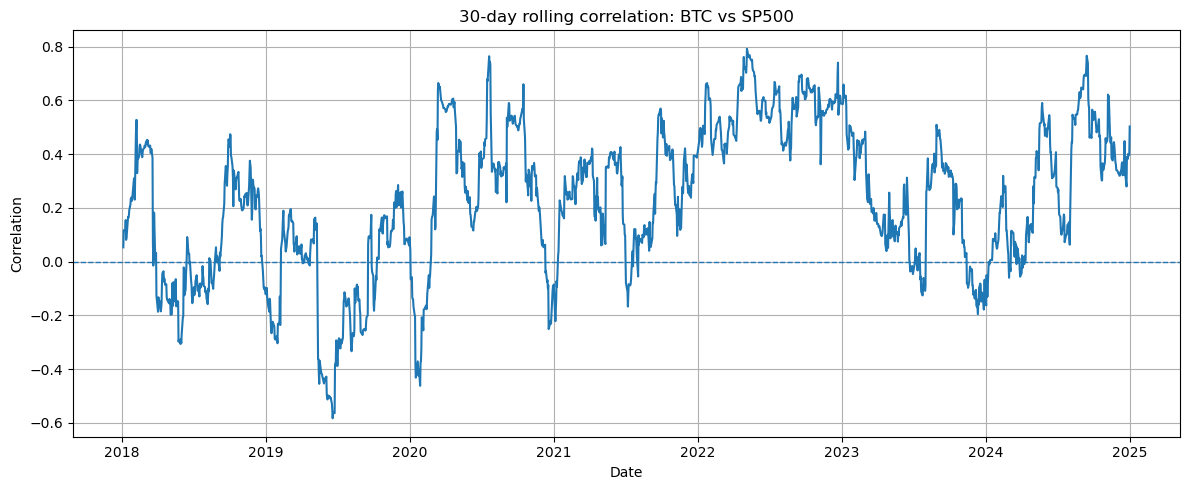

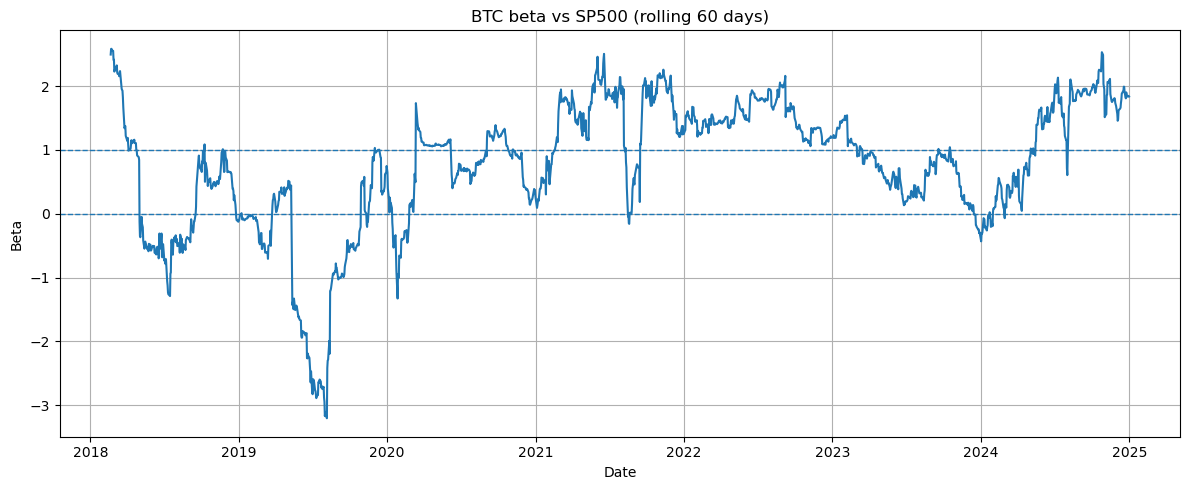

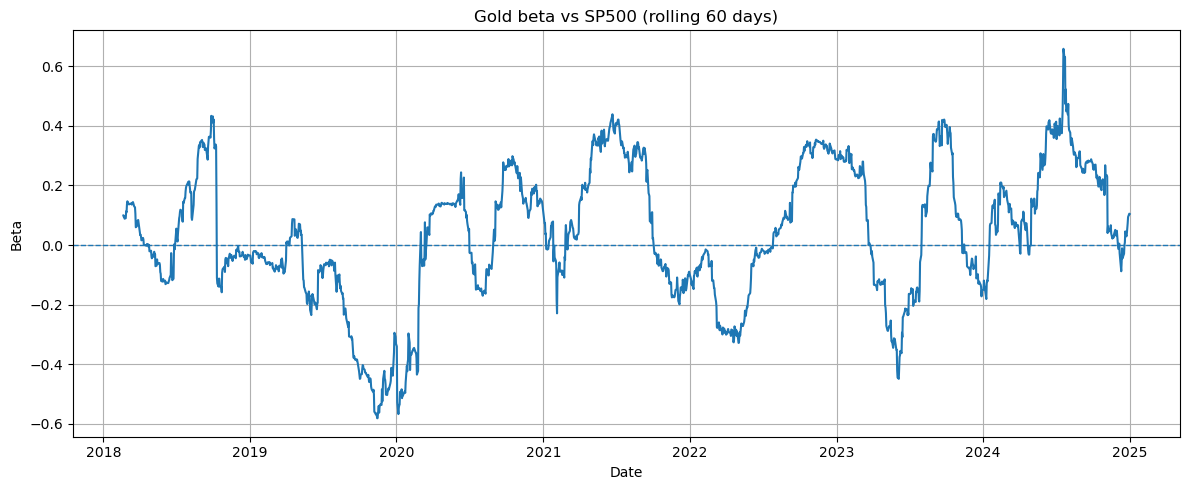

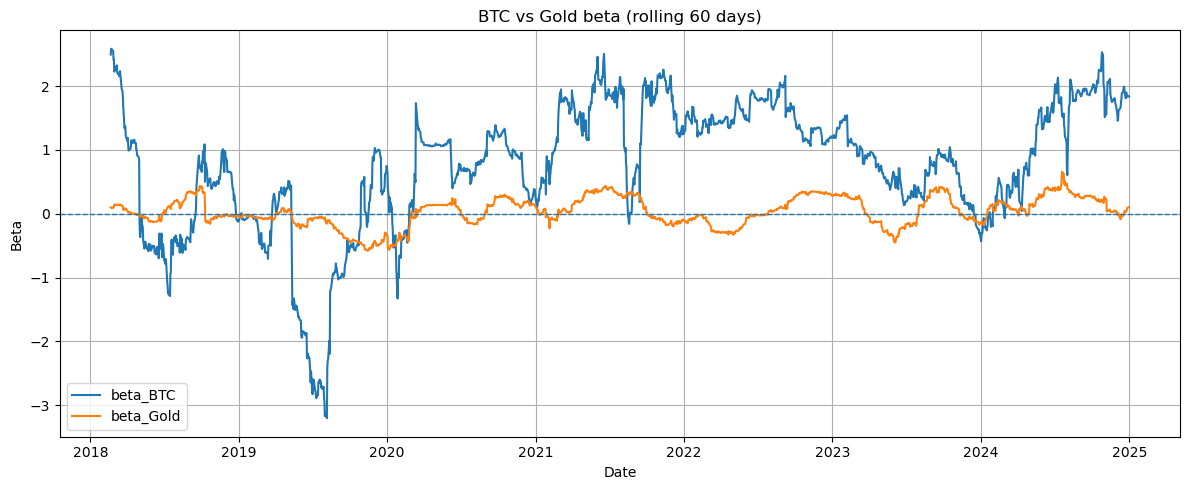

In [3]:
# Rolling correlation BTC–SP500
plt.figure(figsize=(12, 5))
plt.plot(df_base.index, df_base["corr_BTC_SP500"], label="corr_BTC_SP500")
plt.axhline(0, linestyle="--", linewidth=1)

plt.title(f"{WINDOW_CORR}-day rolling correlation: BTC vs SP500")
plt.xlabel("Date")
plt.ylabel("Correlation")
plt.grid(True)
plt.tight_layout()
plt.show()

# Rolling beta BTC vs SP500

WINDOW_BETA = 60

# Rolling covariance between BTC and SP500
cov_btc = df_base["ret_BTC"].rolling(WINDOW_BETA).cov(df_base["ret_SP500"])

# Rolling variance of SP500
var_sp = df_base["ret_SP500"].rolling(WINDOW_BETA).var()

# Beta = Cov(BTC, SP500) / Var(SP500)
beta_btc = cov_btc / var_sp
beta_btc.name = "beta_BTC"

plt.figure(figsize=(12, 5))
plt.plot(beta_btc.index, beta_btc, label="beta_BTC")
plt.axhline(0, linestyle="--", linewidth=1)
plt.axhline(1, linestyle="--", linewidth=1)

plt.title(f"BTC beta vs SP500 (rolling {WINDOW_BETA} days)")
plt.xlabel("Date")
plt.ylabel("Beta")
plt.grid(True)
plt.tight_layout()
plt.show()


# Rolling beta Gold vs SP500

cov_gold = df_base["ret_Gold"].rolling(WINDOW_BETA).cov(df_base["ret_SP500"])
beta_gold = cov_gold / var_sp
beta_gold.name = "beta_Gold"

plt.figure(figsize=(12, 5))
plt.plot(beta_gold.index, beta_gold, label="beta_Gold")
plt.axhline(0, linestyle="--", linewidth=1)

plt.title(f"Gold beta vs SP500 (rolling {WINDOW_BETA} days)")
plt.xlabel("Date")
plt.ylabel("Beta")
plt.grid(True)
plt.tight_layout()
plt.show()


# BTC vs Gold beta comparison

plt.figure(figsize=(12, 5))
plt.plot(beta_btc.index, beta_btc, label="beta_BTC")
plt.plot(beta_gold.index, beta_gold, label="beta_Gold")

plt.axhline(0, linestyle="--", linewidth=1)

plt.title(f"BTC vs Gold beta (rolling {WINDOW_BETA} days)")
plt.xlabel("Date")
plt.ylabel("Beta")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [4]:
def build_regression_dataset(df, horizon=5):

    # Target = future BTC volatility
    target = df["vol_BTC"].shift(-horizon)

    # Base features
    features = pd.DataFrame(index=df.index)
    features["vol_BTC"] = df["vol_BTC"]
    features["vol_SP500"] = df["vol_SP500"]
    features["vol_Gold"] = df["vol_Gold"]
    features["corr_BTC_SP500"] = df["corr_BTC_SP500"]
    features["VIX"] = df["VIX"]

    # Include returns as macro factors
    features["ret_BTC"] = df["ret_BTC"]
    features["ret_SP500"] = df["ret_SP500"]
    features["ret_Gold"] = df["ret_Gold"]
    features["ret_VIX"] = df["ret_VIX"]

    # Add lagged features
    for lag in [1, 5, 10]:
        features[f"vol_BTC_lag{lag}"] = df["vol_BTC"].shift(lag)
        features[f"corr_lag{lag}"] = df["corr_BTC_SP500"].shift(lag)
        features[f"VIX_lag{lag}"] = df["VIX"].shift(lag)
        features[f"ret_BTC_lag{lag}"] = df["ret_BTC"].shift(lag)

    # Clean final dataset
    full = pd.concat([features, target.rename("target_vol_BTC_future")], axis=1)
    full = full.dropna()

    X = full.drop(columns=["target_vol_BTC_future"])
    y = full["target_vol_BTC_future"]

    return X, y

In [5]:
# Build the regression dataset
X_reg, y_reg = build_regression_dataset(df, horizon=HORIZON)

# Time-based split 
train_mask = (X_reg.index < "2022-01-01")
test_mask  = (X_reg.index >= "2022-01-01")

X_train_reg, y_train_reg = X_reg[train_mask], y_reg[train_mask]
X_test_reg,  y_test_reg  = X_reg[test_mask],  y_reg[test_mask]


In [6]:
# GARCH

# Train/test date boundaries 
TRAIN_START = "2018-01-01"
TRAIN_END   = "2021-12-31"
TEST_START  = "2022-01-01"
TEST_END    = "2025-01-01"


# Rendements BTC en % sur TOUTE la période
btc_ret_pct = df_base["ret_BTC"].dropna() * 100

print("BTC returns full sample:", btc_ret_pct.index.min(), "->", btc_ret_pct.index.max())

# Modèle GARCH(1,1) estimé en utilisant seulement les données jusqu'à TRAIN_END
am = arch_model(
    btc_ret_pct,
    mean="Zero",
    vol="GARCH",
    p=1,
    q=1,
    dist="normal"
)

# last_obs = fin de l'échantillon de training
res_garch = am.fit(last_obs=TRAIN_END, disp="off", update_freq=0)
print(res_garch.summary())

# Prévisions 1-step-ahead dynamiques à partir du début de la période de test
fcst = res_garch.forecast(horizon=1, start=TEST_START, reindex=True)

# Variance en %^2 -> vol en "return units"
sigma2_test_pct2 = fcst.variance.loc[TEST_START:TEST_END, "h.1"]
garch_vol = np.sqrt(sigma2_test_pct2) / 100
garch_vol.name = "garch_vol_BTC"

# --- 7) Realized volatility (30-day rolling) from df_base for the same dates ---

# Volatilité réalisée au temps t (comme avant)
realized_vol_t = df_base["vol_BTC"].loc[garch_vol.index]
realized_vol_t.name = "realized_vol_BTC_t"

# Volatilité réalisée au temps t+1 (pour comparaison propre avec la prévision GARCH(t))
realized_vol_tplus1 = df_base["vol_BTC"].shift(-1).loc[garch_vol.index]
realized_vol_tplus1.name = "realized_vol_BTC_tplus1"

# --- 8) Tableau final pour GARCH ---
garch_vs_realized = pd.concat(
    [realized_vol_t, realized_vol_tplus1, garch_vol],
    axis=1
).dropna()

print("\nGARCH vs realized volatility (test period):")
print(garch_vs_realized.head())
print("\nNumber of aligned observations:", len(garch_vs_realized))



BTC returns full sample: 2017-11-21 00:00:00 -> 2024-12-31 00:00:00
                       Zero Mean - GARCH Model Results                        
Dep. Variable:                ret_BTC   R-squared:                       0.000
Mean Model:                 Zero Mean   Adj. R-squared:                  0.001
Vol Model:                      GARCH   Log-Likelihood:               -3054.44
Distribution:                  Normal   AIC:                           6114.87
Method:            Maximum Likelihood   BIC:                           6129.69
                                        No. Observations:                 1033
Date:                Mon, Nov 24 2025   Df Residuals:                     1033
Time:                        11:02:06   Df Model:                            0
                              Volatility Model                             
                 coef    std err          t      P>|t|     95.0% Conf. Int.
---------------------------------------------------------------------

In [7]:
# Random Forest model on regression dataset

# Define the model
rf_model = RandomForestRegressor(
    n_estimators=300,
    min_samples_split=5,
    min_samples_leaf=3,
    random_state=42,
    n_jobs=-1
)

# Fit on training period (2018–2021)
rf_model.fit(X_train_reg, y_train_reg)

# Predict on test period (2022–2025)
y_pred_rf = rf_model.predict(X_test_reg)

# Error metrics
rmse_rf = np.sqrt(mean_squared_error(y_test_reg, y_pred_rf))  # RMSE
mae_rf  = mean_absolute_error(y_test_reg, y_pred_rf)

print("\n=== Random Forest — performance sur la période test ===")
print(f"RMSE : {rmse_rf:.6f}")
print(f"MAE  : {mae_rf:.6f}")

# Build results table: true future vol vs RF (and GARCH if available)
rf_results = pd.DataFrame(
    {
        "target_vol_BTC_future": y_test_reg,   # same name as in build_regression_dataset
        "rf_vol_pred": y_pred_rf,
    },
    index=y_test_reg.index
)


# If GARCH results already computed, align on common dates
if "garch_vs_realized" in globals():
    common_idx = rf_results.index.intersection(garch_vs_realized.index)
    rf_results = rf_results.loc[common_idx].copy()
    
    rf_results["garch_vol_BTC"]           = garch_vs_realized.loc[common_idx, "garch_vol_BTC"]
    rf_results["realized_vol_BTC_t"]      = garch_vs_realized.loc[common_idx, "realized_vol_BTC_t"]
    rf_results["realized_vol_BTC_tplus1"] = garch_vs_realized.loc[common_idx, "realized_vol_BTC_tplus1"]

print("\nPreview of RF results (and GARCH if present):")
print(rf_results.head())
print("\nNumber of observations in rf_results:", len(rf_results))



=== Random Forest — performance sur la période test ===
RMSE : 0.006180
MAE  : 0.004446

Preview of RF results (and GARCH if present):
            target_vol_BTC_future  rf_vol_pred  garch_vol_BTC  \
Date                                                            
2022-01-03               0.032779     0.033661       0.038185   
2022-01-04               0.029264     0.033942       0.037205   
2022-01-05               0.030063     0.033356       0.040502   
2022-01-06               0.030243     0.034079       0.039026   
2022-01-07               0.030493     0.034325       0.039929   

            realized_vol_BTC_t  realized_vol_BTC_tplus1  
Date                                                     
2022-01-03            0.033374                 0.032984  
2022-01-04            0.032984                 0.033686  
2022-01-05            0.033686                 0.033173  
2022-01-06            0.033173                 0.033494  
2022-01-07            0.033494                 0.032779  

N

In [8]:
# Gradient Boosting model

# Define the model
gb_model = GradientBoostingRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=3,
    subsample=1.0,
    random_state=42
)

# Fit on training sample
gb_model.fit(X_train_reg, y_train_reg)

# Predict on test sample
y_pred_gb = gb_model.predict(X_test_reg)

# Evaluation metrics
rmse_gb = np.sqrt(mean_squared_error(y_test_reg, y_pred_gb))
mae_gb  = mean_absolute_error(y_test_reg, y_pred_gb)

print("\n=== Gradient Boosting — test performance ===")
print(f"RMSE : {rmse_gb:.6f}")
print(f"MAE  : {mae_gb:.6f}")

# Convert predictions to a clean Series
gb_pred_series = pd.Series(y_pred_gb, index=X_test_reg.index, name="gb_vol_pred")

# Add GB predictions to the existing result table
gb_results = rf_results.copy()
gb_results["gb_vol_pred"] = gb_pred_series.loc[gb_results.index]

# Reorder columns: t+5 models first, then realized and GARCH
cols_order = [
    "target_vol_BTC_future",   # true future volatility (t+5)
    "rf_vol_pred",             # Random Forest prediction
    "gb_vol_pred",             # Gradient Boosting prediction
    "realized_vol_BTC_t",      # realized vol at time t
    "realized_vol_BTC_tplus1", # realized vol at t+1
    "garch_vol_BTC"            # GARCH one-step-ahead prediction (t+1)
]

# Keep only columns that exist
cols_order = [c for c in cols_order if c in gb_results.columns]
gb_results = gb_results[cols_order]

print("\nPreview of results (RF, GB, GARCH, realized):")
print(gb_results.head())
print("\nNumber of observations in gb_results:", len(gb_results))



=== Gradient Boosting — test performance ===
RMSE : 0.005995
MAE  : 0.004134

Preview of results (RF, GB, GARCH, realized):
            target_vol_BTC_future  rf_vol_pred  gb_vol_pred  \
Date                                                          
2022-01-03               0.032779     0.033661     0.031440   
2022-01-04               0.029264     0.033942     0.031411   
2022-01-05               0.030063     0.033356     0.032200   
2022-01-06               0.030243     0.034079     0.032749   
2022-01-07               0.030493     0.034325     0.032326   

            realized_vol_BTC_t  realized_vol_BTC_tplus1  garch_vol_BTC  
Date                                                                    
2022-01-03            0.033374                 0.032984       0.038185  
2022-01-04            0.032984                 0.033686       0.037205  
2022-01-05            0.033686                 0.033173       0.040502  
2022-01-06            0.033173                 0.033494       0.0390

In [9]:
# ML model: XGBoost (t+5 forecasting)

# XGBoost works best with float32
X_train_xgb = X_train_reg.astype("float32")
X_test_xgb  = X_test_reg.astype("float32")
y_train_xgb = y_train_reg.astype("float32")
y_test_xgb  = y_test_reg.astype("float32")

# Define the XGBoost model
xgb_model = XGBRegressor(
    n_estimators=600,
    learning_rate=0.03,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

# Fit on training data
xgb_model.fit(X_train_xgb, y_train_xgb)

# Predict on test period
y_pred_xgb = xgb_model.predict(X_test_xgb)

# Error metrics
rmse_xgb = np.sqrt(mean_squared_error(y_test_xgb, y_pred_xgb))
mae_xgb  = mean_absolute_error(y_test_xgb, y_pred_xgb)

print("\n=== XGBoost — test performance ===")
print(f"RMSE : {rmse_xgb:.6f}")
print(f"MAE  : {mae_xgb:.6f}")

# XGB predictions aligned on test index
xgb_pred_series = pd.Series(y_pred_xgb, index=X_test_reg.index, name="xgb_vol_pred")

# Start from GB results if they exist, otherwise from RF results
if "gb_results" in globals():
    xgb_results = gb_results.copy()
else:
    xgb_results = rf_results.copy()

xgb_results["xgb_vol_pred"] = xgb_pred_series.loc[xgb_results.index]

# Reorder columns: RF, GB, XGB (t+5) then realized & GARCH
cols_order = [
    "target_vol_BTC_future",
    "rf_vol_pred",
    "gb_vol_pred",
    "xgb_vol_pred",
    "realized_vol_BTC_t",
    "realized_vol_BTC_tplus1",
    "garch_vol_BTC",
]
cols_order = [c for c in cols_order if c in xgb_results.columns]
xgb_results = xgb_results[cols_order]

print("\nPreview of results (RF, GB, XGB, GARCH, realized):")
print(xgb_results.head())
print("\nNumber of observations in xgb_results:", len(xgb_results))



=== XGBoost — test performance ===
RMSE : 0.005811
MAE  : 0.003975

Preview of results (RF, GB, XGB, GARCH, realized):
            target_vol_BTC_future  rf_vol_pred  gb_vol_pred  xgb_vol_pred  \
Date                                                                        
2022-01-03               0.032779     0.033661     0.031440      0.031519   
2022-01-04               0.029264     0.033942     0.031411      0.031845   
2022-01-05               0.030063     0.033356     0.032200      0.031873   
2022-01-06               0.030243     0.034079     0.032749      0.032683   
2022-01-07               0.030493     0.034325     0.032326      0.033056   

            realized_vol_BTC_t  realized_vol_BTC_tplus1  garch_vol_BTC  
Date                                                                    
2022-01-03            0.033374                 0.032984       0.038185  
2022-01-04            0.032984                 0.033686       0.037205  
2022-01-05            0.033686                 0

In [10]:
# Final model evaluation: RMSE / MAE comparison table

from sklearn.metrics import mean_squared_error, mean_absolute_error

# Build evaluation table using the test set (t+5 horizon)
all_results = pd.DataFrame(index=y_test_reg.index)
all_results["target"] = y_test_reg   # true t+5 volatility

# Add model predictions (aligned automatically using the index)

# Random Forest
if "y_pred_rf" in globals():
    all_results["rf"] = pd.Series(y_pred_rf, index=y_test_reg.index)

# Gradient Boosting
if "y_pred_gb" in globals():
    all_results["gb"] = pd.Series(y_pred_gb, index=y_test_reg.index)

# XGBoost
if "y_pred_xgb" in globals():
    all_results["xgb"] = pd.Series(y_pred_xgb, index=y_test_reg.index)

# GARCH (1-step ahead, t+1 horizon)
if "garch_vs_realized" in globals():
    # align on common dates
    common_idx = all_results.index.intersection(garch_vs_realized.index)
    all_results = all_results.loc[common_idx]
    all_results["garch"] = garch_vs_realized.loc[common_idx, "garch_vol_BTC"]

print("\nPreview of evaluation table:")
print(all_results.head())
print("\nColumns:", list(all_results.columns))


# Helper function to compute metrics
def compute_metrics(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    return rmse, mae


# Compute metrics for each model
metrics_dict = {}

for model in all_results.columns[1:]:   # skip "target"
    rmse, mae = compute_metrics(all_results["target"], all_results[model])
    metrics_dict[model] = {"RMSE": rmse, "MAE": mae}

# Create summary table
summary_table = pd.DataFrame(metrics_dict).T
summary_table = summary_table[["RMSE", "MAE"]]

print("\n=== Summary of model performance ===")
print(summary_table)



Preview of evaluation table:
              target        rf        gb       xgb     garch
Date                                                        
2022-01-03  0.032779  0.033661  0.031440  0.031519  0.038185
2022-01-04  0.029264  0.033942  0.031411  0.031845  0.037205
2022-01-05  0.030063  0.033356  0.032200  0.031873  0.040502
2022-01-06  0.030243  0.034079  0.032749  0.032683  0.039026
2022-01-07  0.030493  0.034325  0.032326  0.033056  0.039929

Columns: ['target', 'rf', 'gb', 'xgb', 'garch']

=== Summary of model performance ===
           RMSE       MAE
rf     0.006180  0.004446
gb     0.005995  0.004134
xgb    0.005811  0.003975
garch  0.010954  0.009269


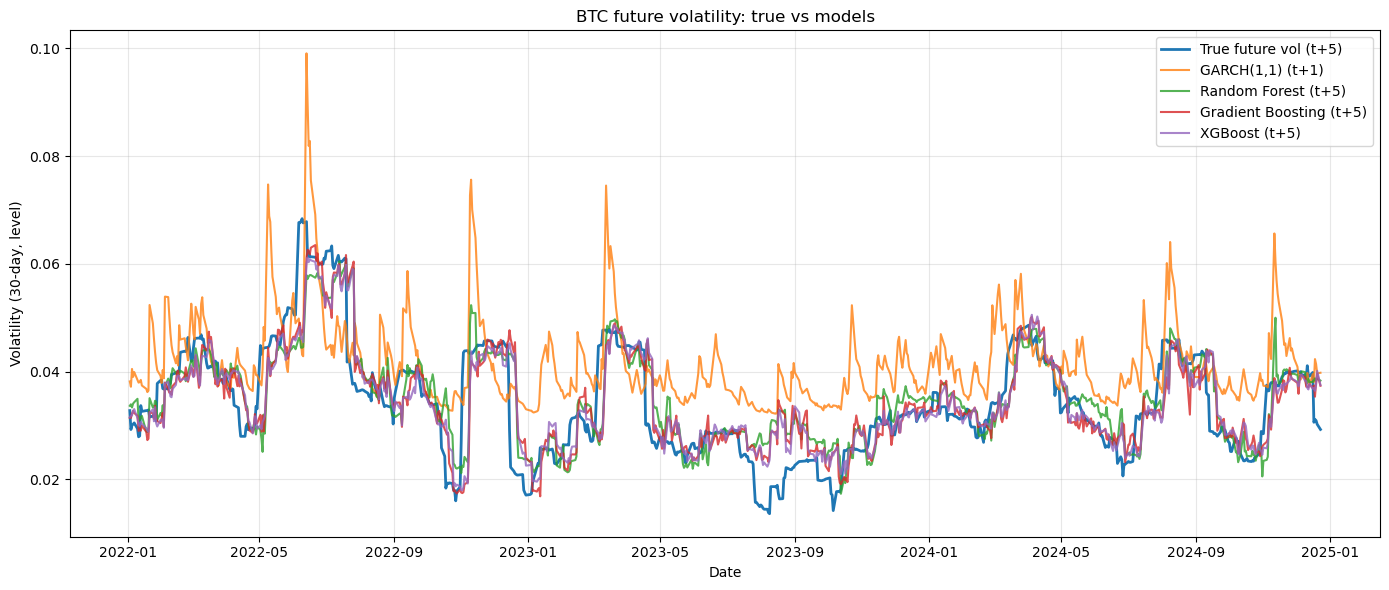

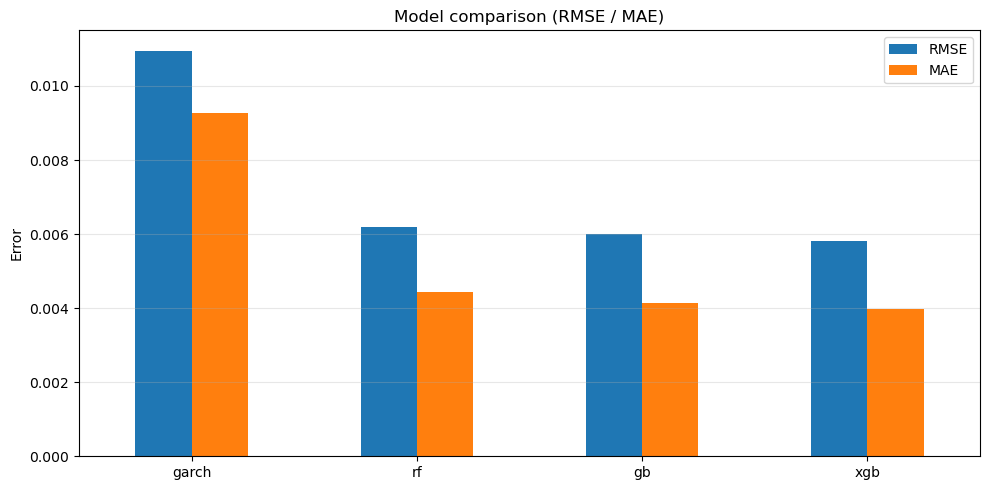

In [11]:
# Visualisation: time series + error comparison

import matplotlib.pyplot as plt

# Time series: true future vol vs models

plt.figure(figsize=(14, 6))

# True target (t+5)
plt.plot(
    all_results.index,
    all_results["target"],
    label="True future vol (t+5)",
    linewidth=2
)

# Other models (only if present in the table)
model_labels = {
    "garch": "GARCH(1,1) (t+1)",
    "rf":    "Random Forest (t+5)",
    "gb":    "Gradient Boosting (t+5)",
    "xgb":   "XGBoost (t+5)",
}

for col, lab in model_labels.items():
    if col in all_results.columns:
        plt.plot(all_results.index, all_results[col], label=lab, alpha=0.8)

plt.title("BTC future volatility: true vs models")
plt.xlabel("Date")
plt.ylabel("Volatility (30-day, level)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


# Bar chart: RMSE / MAE per model 

# Ensure correct order of rows (if they exist)
row_order = [m for m in ["garch", "rf", "gb", "xgb"] if m in summary_table.index]
summary_for_plot = summary_table.loc[row_order]

ax = summary_for_plot.plot(kind="bar", figsize=(10, 5))
ax.set_title("Model comparison (RMSE / MAE)")
ax.set_ylabel("Error")
ax.grid(axis="y", alpha=0.3)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


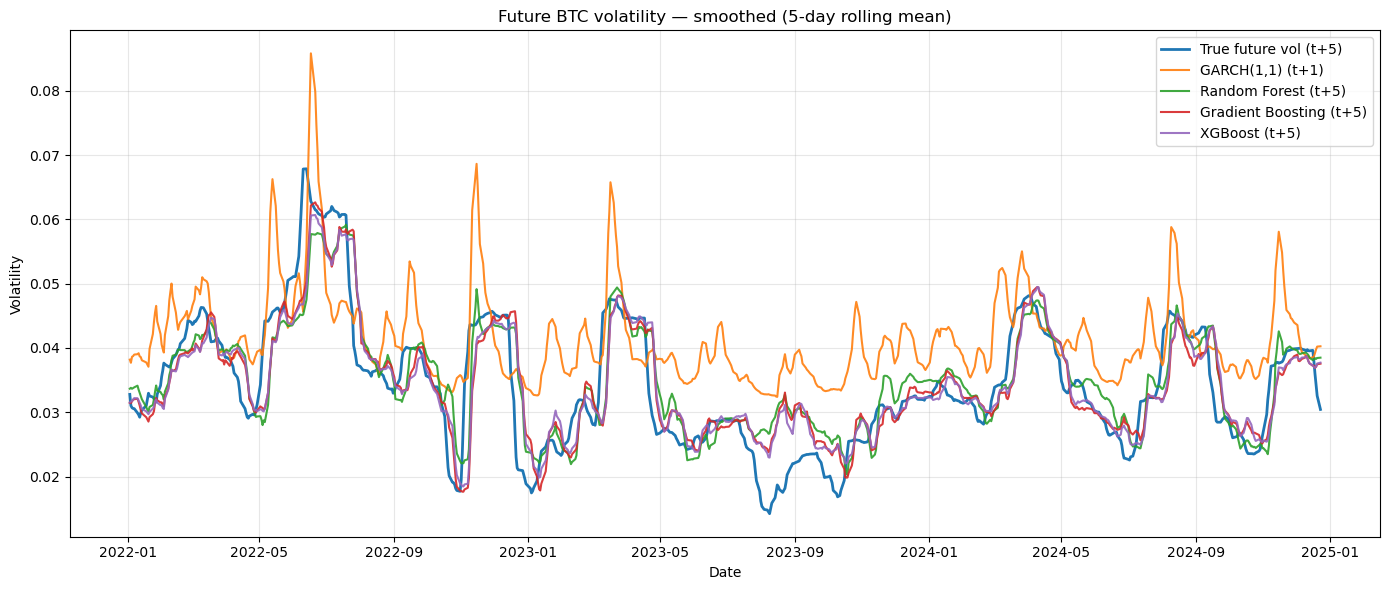

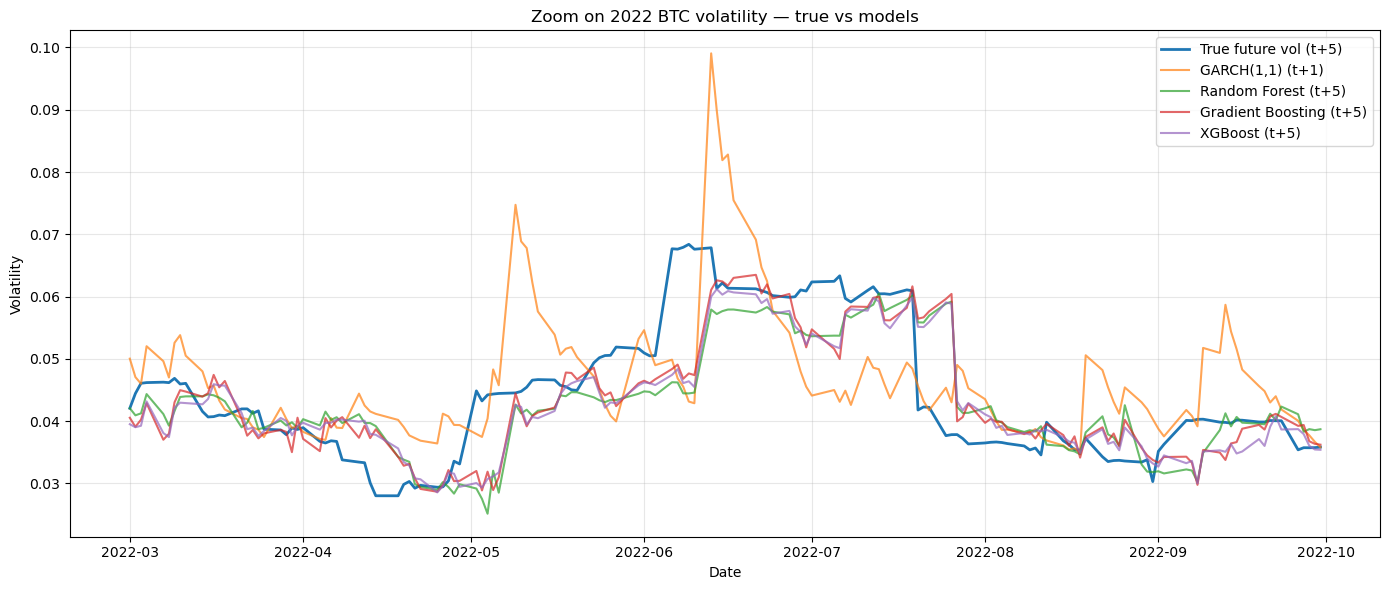

In [15]:
# Smoothed and zoomed plots

# Smoothed time series
SMOOTH_WINDOW = 5  # rolling window size

# keep min_periods=1 so we don't lose the beginning of the sample
smooth_results = all_results.rolling(window=SMOOTH_WINDOW, min_periods=1).mean()

plt.figure(figsize=(14, 6))
plt.plot(
    smooth_results.index,
    smooth_results["target"],
    label="True future vol (t+5)",
    linewidth=2
)

labels = {
    "garch": "GARCH(1,1) (t+1)",
    "rf":    "Random Forest (t+5)",
    "gb":    "Gradient Boosting (t+5)",
    "xgb":   "XGBoost (t+5)",
}

for col, lab in labels.items():
    if col in smooth_results.columns:
        plt.plot(smooth_results.index, smooth_results[col], label=lab, alpha=0.9)

plt.title(f"Future BTC volatility — smoothed ({SMOOTH_WINDOW}-day rolling mean)")
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


# Zoom on a specific period
zoom = all_results.loc["2022-03":"2022-09"]

plt.figure(figsize=(14, 6))
plt.plot(zoom.index, zoom["target"], label="True future vol (t+5)", linewidth=2)

for col, lab in labels.items():
    if col in zoom.columns:
        plt.plot(zoom.index, zoom[col], label=lab, alpha=0.7)

plt.title("Zoom on 2022 BTC volatility — true vs models")
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()



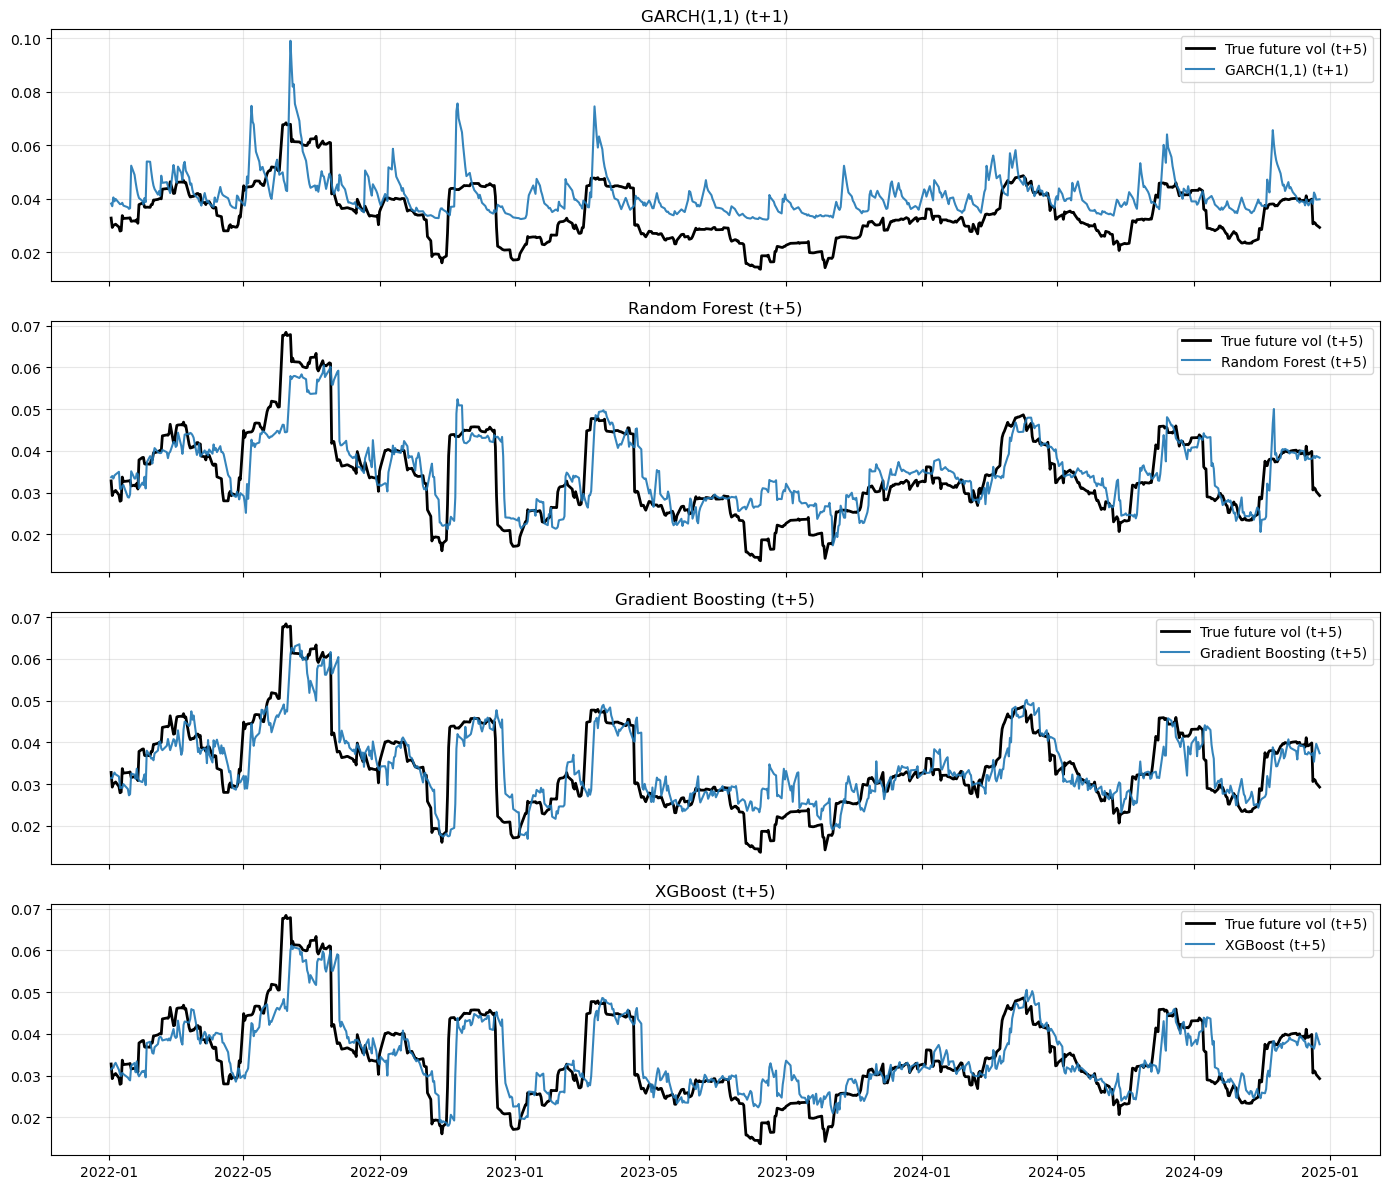

In [16]:
# Multi-panel comparison

fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)

models = ["garch", "rf", "gb", "xgb"]
labels = {
    "garch": "GARCH(1,1) (t+1)",
    "rf":    "Random Forest (t+5)",
    "gb":    "Gradient Boosting (t+5)",
    "xgb":   "XGBoost (t+5)",
}

for ax, model in zip(axes, models):

    # Skip if model does not exist in all_results
    if model not in all_results.columns:
        ax.set_visible(False)
        continue

    # True future volatility (target)
    ax.plot(
        all_results.index,
        all_results["target"],
        label="True future vol (t+5)",
        linewidth=2,
        color="black"
    )

    # Model curve
    ax.plot(
        all_results.index,
        all_results[model],
        label=labels[model],
        alpha=0.9
    )

    ax.set_title(labels[model], fontsize=12)
    ax.grid(True, alpha=0.3)
    ax.legend(loc="upper right")

plt.tight_layout()
plt.show()
